# Implementación de Red Neuronal MLP para clasificación de Fashion-MNIST

## Introducción

En este proyecto, implementaremos una red neuronal artificial multicapa (MLP) para resolver un problema de clasificación de imágenes utilizando el conjunto de datos Fashion-MNIST. Este dataset contiene 70,000 imágenes en escala de grises de 28x28 píxeles, representando 10 categorías diferentes de productos de moda. El conjunto se divide en 60,000 imágenes para entrenamiento y 10,000 para pruebas.

Las 10 clases de Fashion-MNIST son:

0. Camiseta/top
1. Pantalón
2. Suéter
3. Vestido
4. Abrigo
5. Sandalia
6. Camisa
7. Zapatilla deportiva
8. Bolso
9. Botín

A diferencia del MNIST tradicional de dígitos escritos a mano, Fashion-MNIST representa un desafío más complejo y realista para los algoritmos de aprendizaje automático. Nuestro objetivo es construir un modelo MLP capaz de clasificar correctamente estas imágenes, aplicando técnicas de deep learning como regularización, optimización y ajuste de hiperparámetros.

## Importación de librerías

In [1]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Métricas y utilidades para evaluación
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Configurar semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

import warnings

# La función filterwarnings se utiliza para modificar la forma en que se manejan las advertencias.
# En este caso, se le pasa el parámetro "ignore" para indicarle a Python que no muestre ninguna advertencia.
warnings.filterwarnings("ignore")

# Verificar disponibilidad de GPU
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


GPU disponible: []


## Carga y preprocesamiento de datos

Cargaremos el conjunto de datos Fashion-MNIST directamente desde Keras, que proporciona una forma sencilla de acceder a este dataset.

In [3]:
# Cargar el conjunto de datos Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Verificar las dimensiones de los datos
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (60000, 28, 28)
Dimensiones de X_test: (10000, 28, 28)
Dimensiones de y_train: (60000,)
Dimensiones de y_test: (10000,)


In [4]:
X_train[5]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172,
        132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242,
        255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150,
        162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162,
        155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187,
        184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210,
        212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  88, 221, 215, 217, 219, 211, 185, 150, 118,
        107,  99,  88,  83,  90, 135, 212, 203, 207, 219, 169,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  27, 118, 162,  40,   0,   0,   0,  10,
         19,  28,  39,  47,  36,   0,   0, 203, 230, 220, 203,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 138, 136,  71,  69,  54, 216, 217, 203, 184,
        168, 163, 162, 163, 178, 221, 186,  38,  26,   7,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  67, 134, 154, 224, 129,  66,  81, 117, 129,
        128, 132, 137, 131, 129,  86,  73, 157, 151, 134, 216,  18,   0,
          0,   0],
       [  0,   0,   0,   0, 203, 198, 172, 183, 206, 255, 255, 250, 243,
        240, 239, 235, 238, 244, 255, 238, 184, 160,  86,  98,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 122, 188, 224, 151, 105, 127,  97, 100, 105,
        114, 117, 117, 113, 103,  98, 111, 142, 254, 191, 255,  49,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 179, 200,  95, 154, 198, 197, 200, 200,
        198, 197, 198, 199, 202, 200, 176,  86, 206, 157, 162,  10,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 201, 229,  71, 144, 194, 181, 183, 179,
        182, 180, 179, 180, 190, 185, 197,  76, 219, 185, 201,  34,   0,
          0,   0],
       [  0,   0,   0,   0, 199, 193, 226,  58, 154, 192, 184, 187, 184,
        186, 184, 185, 183, 192, 191, 200,  56, 219, 203, 207,  60,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 194, 224,  41, 163, 190, 186, 186, 184,
        185, 183, 185, 178, 190, 194, 202,  33, 211, 200, 206,  73,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 197, 222,  17, 172, 190, 186, 187, 182,
        186, 185, 187, 180, 187, 193, 202,  26, 212, 202, 203,  76,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 177, 189, 184, 185, 178,
        184, 183, 184, 180, 183, 189, 203,  35, 196, 203, 203,  84,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 185, 187, 185, 187, 180,
        184, 182, 183, 178, 182, 183, 205,  44, 159, 207, 201,  85,   0,
          0,   0],
       [  0,   0,   0,   0, 187, 198, 225,   0, 194, 188, 184, 185, 180,
        183, 183, 184, 181, 181, 177, 206,  46, 129, 211, 200,  88,   0,
          0,   0],
       [  0,   0,   0,   6, 186, 200, 211,   0, 199, 189, 184, 184, 185,
        182, 183, 184, 185, 182, 175, 205,  50,  97, 216, 197,  93,   0,
          0,   0],
       [  0,   0,   0,   5, 185, 204, 184,   0, 202, 188, 182, 182, 183,
        183, 184, 182, 180, 182, 174, 202,  63,  59, 220, 196,  94,   0,
          0,   0],
       [  0,   0,   0,   5, 184, 206, 157,   0, 204, 187, 187, 189, 192,
        190, 190, 191, 190, 187, 183, 202,  78,  35, 222, 197,  95,   0,
          0,   0],
       [  0,   0,   0,   5, 183, 208, 127,   0, 197, 166, 153, 149, 149,
        146, 148, 149, 150, 151, 158, 191,  90,   8, 223, 195,  99,   0,
          0,   0],
       [  0,   0,   0,   6, 184, 208, 11

### Exploración visual de los datos

Visualizaremos algunas imágenes del conjunto de datos para entender mejor con qué estamos trabajando:

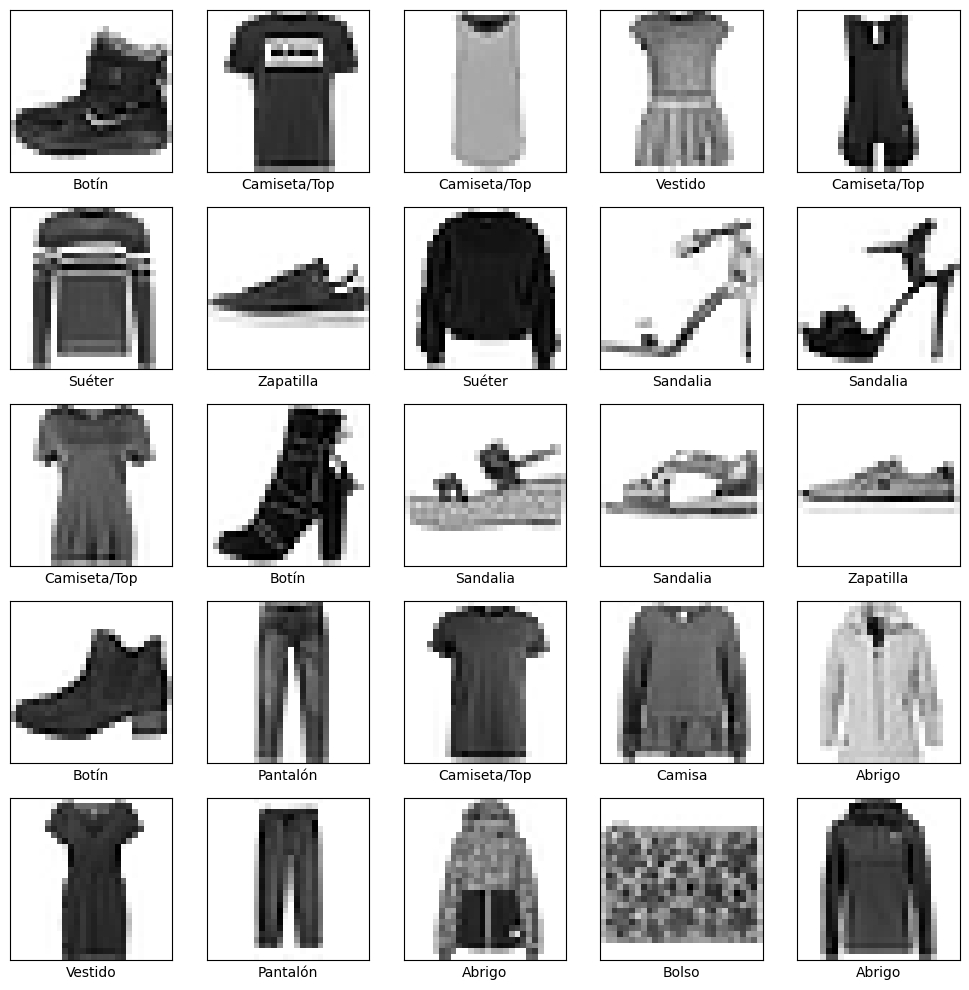

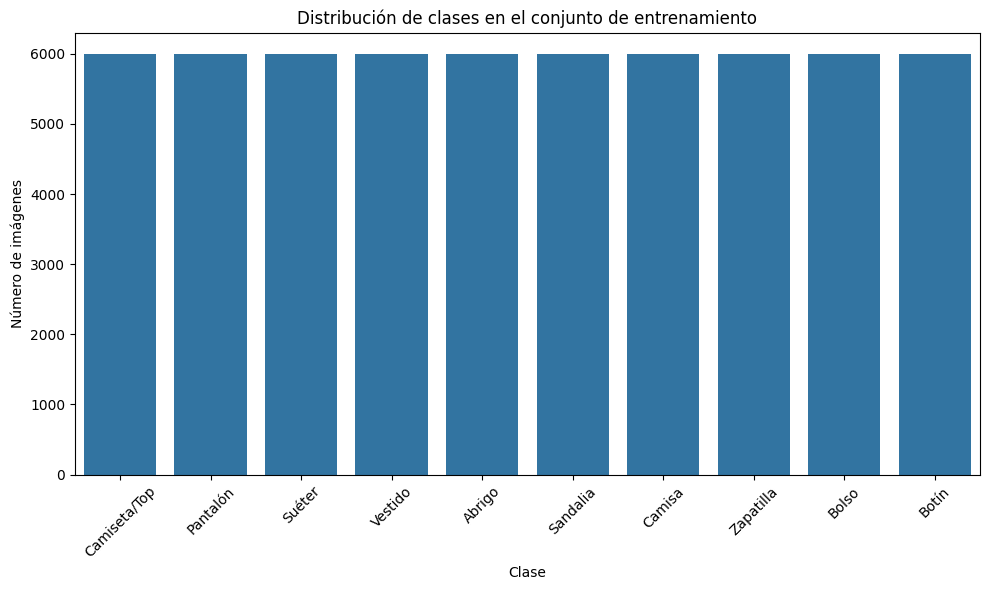

In [5]:
# Nombre de las clases para las etiquetas
class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Visualizar algunas imágenes
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

# Distribución de clases en el conjunto de entrenamiento
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title('Distribución de clases en el conjunto de entrenamiento')
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.xticks(range(10), class_names, rotation=45)
plt.tight_layout()
plt.show()

### Preprocesamiento de datos

Ahora, realizaremos el preprocesamiento necesario para preparar los datos para el entrenamiento:

1. Normalización: Escalaremos los valores de píxeles del rango [0, 255] al rango [0, 1]
2. Reshape: Transformaremos las imágenes 2D en vectores 1D
3. One-hot encoding: Convertiremos las etiquetas numéricas en vectores one-hot

In [6]:
# Normalización: escalar los valores de píxeles a [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape: transformar imágenes 2D en vectores 1D
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Dimensiones de X_train_flat:", X_train_flat.shape)
print("Dimensiones de X_test_flat:", X_test_flat.shape)

# One-hot encoding para las etiquetas
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print("Dimensiones de y_train_onehot:", y_train_onehot.shape)
print("Dimensiones de y_test_onehot:", y_test_onehot.shape)

# Separar un conjunto de validación del conjunto de entrenamiento
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_flat, y_train_onehot, test_size=0.2, random_state=42
)

print("Dimensiones de X_train_final:", X_train_final.shape)
print("Dimensiones de X_val:", X_val.shape)

Dimensiones de X_train_flat: (60000, 784)
Dimensiones de X_test_flat: (10000, 784)
Dimensiones de y_train_onehot: (60000, 10)
Dimensiones de y_test_onehot: (10000, 10)
Dimensiones de X_train_final: (48000, 784)
Dimensiones de X_val: (12000, 784)


## Definición del modelo MLP

Crearemos varios modelos MLP con diferentes configuraciones para comparar su rendimiento. Comenzaremos con un modelo básico y luego iremos añadiendo capas, regularización y ajustando hiperparámetros.

### Modelo 1: MLP Básico

In [7]:
def create_basic_mlp():
    # Creamos un modelo secuencial. En este tipo de modelo, las capas se apilan de forma lineal.
    model = Sequential([
        # Primera capa: Capa de entrada y primera capa oculta.
        # - input_shape=(784,): Cada muestra de entrada es un vector de 784 elementos (por ejemplo, una imagen 28x28 píxeles aplanada).
        # - Dense(128, ...): Crea una capa con 128 neuronas.
        # - activation='relu': Aplica la función de activación ReLU (Rectified Linear Unit), que ayuda a introducir no linealidades.
        Dense(128, activation='relu', input_shape=(784,)),

        # Segunda capa: Capa oculta adicional con 64 neuronas.
        # - Dense(64, ...): Crea una capa con 64 neuronas.
        # - activation='relu': Se utiliza nuevamente la función ReLU para manejar las no linealidades.
        Dense(64, activation='relu'),

        # Tercera capa: Capa de salida.
        # - Dense(10, ...): Crea una capa con 10 neuronas, una por cada clase a predecir.
        # - activation='softmax': Aplica la función de activación softmax, que convierte las salidas en una distribución de probabilidad,
        #   lo cual es ideal para problemas de clasificación multiclase (por ejemplo, dígitos del 0 al 9).
        Dense(10, activation='softmax')
    ])

    # Compilar el modelo.
    # - optimizer='adam': Utiliza el algoritmo Adam para ajustar los pesos durante el entrenamiento.
    # - loss='categorical_crossentropy': Emplea la función de pérdida de entropía cruzada categórica, adecuada para clasificación con etiquetas one-hot.
    # - metrics=['accuracy']: Además de la pérdida, se evalúa la métrica de precisión (accuracy) durante el entrenamiento y prueba.
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Devolver el modelo compilado.
    return model

# Crear el modelo utilizando la función definida.
model1 = create_basic_mlp()

# Imprimir un resumen del modelo que muestra la arquitectura, el número de parámetros por capa y el total de parámetros entrenables.
model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### ⚙️ **¿De dónde salen los parámetros?**

1. **`dense_3`:**  
   - Entrada: 784 (28x28 pixeles de las imágenes)
   - Neuronas: 128  
   - Cálculo: `(784 * 128) + 128 (bias) = 100.480`

2. **`dense_4`:**  
   - Entrada: 128  
   - Neuronas: 64  
   - Cálculo: `(128 * 64) + 64 = 8.256`

3. **`dense_5`:**  
   - Entrada: 64  
   - Neuronas (salida): 10  
   - Cálculo: `(64 * 10) + 10 = 650`

### Modelo 2: MLP con Dropout y BatchNormalization

In [8]:
def create_regularized_mlp():
    # Definimos un modelo secuencial que apila las capas de forma lineal
    model = Sequential([
        # Capa de entrada:
        # - Dense(256, activation='relu', input_shape=(784,))
        #   Crea una capa completamente conectada (fully connected) con 256 neuronas y función de activación ReLU.
        #   La forma de entrada es un vector de 784 elementos (por ejemplo, una imagen de 28x28 píxeles aplanada).
        Dense(256, activation='relu', input_shape=(784,)),

        # Aplicar Batch Normalization:
        # - Normaliza la salida de la capa anterior para estabilizar y acelerar el entrenamiento.
        BatchNormalization(),

        # Aplicar Dropout:
        # - Dropout(0.3) descarta el 30% de las neuronas de forma aleatoria en cada actualización de entrenamiento,
        #   lo que ayuda a prevenir el sobreajuste.
        Dropout(0.3),

        # Primera capa oculta:
        # - Crea una capa con 128 neuronas y función de activación ReLU.
        Dense(128, activation='relu'),

        # Normalización de lotes después de la primera capa oculta.
        BatchNormalization(),

        # Aplicar Dropout con 30% de abandono.
        Dropout(0.3),

        # Segunda capa oculta:
        # - Crea una capa con 64 neuronas y función de activación ReLU.
        Dense(64, activation='relu'),

        # Normalización de lotes
        BatchNormalization(),

        # Aplicar Dropout con 30% de abandono.
        Dropout(0.3),

        # Capa de salida:
        # - Dense(10, activation='softmax') crea una capa con 10 neuronas, una por cada clase de salida.
        # - La función de activación softmax convierte la salida en una distribución de probabilidad para clasificación multiclase.
        Dense(10, activation='softmax')
    ])

    # Compilación del modelo:
    # - Optimizer: Se utiliza Adam con una tasa de aprendizaje de 0.001, que es adecuado para una convergencia eficiente.
    # - Loss: Se define la función de pérdida 'categorical_crossentropy', apropiada para clasificación multiclase con etiquetas codificadas en one-hot.
    # - Metrics: Se evalúa el rendimiento del modelo mediante la métrica de 'accuracy' (precisión).
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Devolver el modelo compilado listo para entrenar
    return model

# Crear el modelo regularizado utilizando la función definida
model2 = create_regularized_mlp()

# Mostrar un resumen de la arquitectura del modelo, incluyendo detalles de cada capa y la cantidad de parámetros.
model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

### Modelo 3: MLP más profundo con más neuronas

In [9]:
def create_deep_mlp():
    # Creamos un modelo secuencial, que permite apilar capas en orden lineal
    model = Sequential([
        # Capa de entrada:
        # - Dense(512, activation='relu', input_shape=(784,)):
        #   Crea una capa completamente conectada con 512 neuronas y función de activación ReLU.
        #   La entrada del modelo es un vector de 784 elementos (por ejemplo, una imagen de 28x28 píxeles aplanada).
        Dense(512, activation='relu', input_shape=(784,)),
        # Normalización de la salida de la capa anterior para estabilizar el entrenamiento.
        BatchNormalization(),
        # Dropout: Desactiva el 40% de las neuronas aleatoriamente para evitar el sobreajuste.
        Dropout(0.4),

        # Primera capa oculta:
        # - Dense(256, activation='relu'): Crea una capa con 256 neuronas que utiliza ReLU.
        Dense(256, activation='relu'),
        # Aplicar Batch Normalization para estabilizar el entrenamiento.
        BatchNormalization(),
        # Dropout: Se aplica con un 40% de probabilidad para reducir el sobreajuste.
        Dropout(0.4),

        # Segunda capa oculta:
        # - Dense(128, activation='relu'): Crea una capa con 128 neuronas utilizando ReLU.
        Dense(128, activation='relu'),
        # Batch Normalization para estabilizar y acelerar el entrenamiento.
        BatchNormalization(),
        # Dropout: Se reduce un poco la probabilidad de desactivación, usando 30%.
        Dropout(0.3),

        # Tercera capa oculta:
        # - Dense(64, activation='relu'): Crea una capa con 64 neuronas utilizando ReLU.
        Dense(64, activation='relu'),
        # Normalización de lotes para mantener consistente la distribución de activaciones.
        BatchNormalization(),
        # Dropout: Disminuye el porcentaje de neuronas desactivadas al 20% en esta capa.
        Dropout(0.2),

        # Capa de salida:
        # - Dense(10, activation='softmax'): Crea la capa de salida con 10 neuronas, una por cada clase.
        #   La activación softmax se utiliza para convertir la salida en probabilidades, ideal para clasificación multiclase.
        Dense(10, activation='softmax')
    ])

    # Compilación del modelo:
    # - optimizer=Adam(learning_rate=0.0005): Se utiliza el optimizador Adam con una tasa de aprendizaje de 0.0005.
    # - loss='categorical_crossentropy': La función de pérdida utilizada para problemas de clasificación multiclase en formato one-hot.
    # - metrics=['accuracy']: Se utiliza la precisión como métrica para evaluar el desempeño del modelo durante el entrenamiento.
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Devuelve el modelo compilado para ser entrenado o evaluado
    return model

# Crear el modelo profundo utilizando la función definida
model3 = create_deep_mlp()

# Mostrar un resumen de la arquitectura del modelo, incluyendo detalles de cada capa y la cantidad de parámetros entrenables
model3.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,890 (2.21 MB)

 Trainable params: 576,970 (2.20 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Entrenamiento y ajuste de hiperparámetros

Entrenaremos cada modelo y compararemos su rendimiento. Para mejorar el entrenamiento, utilizaremos callbacks como EarlyStopping, ModelCheckpoint y ReduceLROnPlateau.

### Entrenamiento del Modelo 1: MLP Básico


In [10]:
# Configuración de callbacks para mejorar el entrenamiento:
# - EarlyStopping: Detiene el entrenamiento si la métrica de validación no mejora después de cierto número de épocas.
#   • patience=10: Espera 10 épocas antes de detener el entrenamiento si no se observa mejora.
#   • restore_best_weights=True: Restaura los pesos del modelo a la época con el mejor rendimiento en validación.
# - ReduceLROnPlateau: Reduce la tasa de aprendizaje cuando la métrica de validación se estanca.
#   • factor=0.5: Reduce la tasa de aprendizaje a la mitad cuando se detecta estancamiento.
#   • patience=5: Espera 5 épocas antes de hacer la reducción.
#   • min_lr=0.00001: No permite que la tasa de aprendizaje baje de este valor.
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=0.00001)
]

# Comienza a medir el tiempo de entrenamiento para el modelo básico (model1)
start_time = time.time()

# Entrenamiento del modelo1 utilizando los datos de entrenamiento y validación:
# - X_train_final, y_train_final: Datos de entrenamiento y sus etiquetas.
# - epochs=50: El modelo se entrenará por un máximo de 50 épocas (aunque podría detenerse antes si se activa EarlyStopping).
# - batch_size=128: Se utiliza un tamaño de lote de 128 muestras por actualización.
# - validation_data=(X_val, y_val): Se proporcionan datos de validación para monitorizar el rendimiento del modelo durante el entrenamiento.
# - callbacks=callbacks: Se aplican las funciones de callback definidas anteriormente.
# - verbose=1: Muestra mensajes detallados del proceso de entrenamiento en la consola.
history1 = model1.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Calcula el tiempo total de entrenamiento restando el tiempo actual al tiempo inicial registrado.
model1_time = time.time() - start_time
print(f"Tiempo de entrenamiento del modelo 1: {model1_time:.2f} segundos")

# Guardar el modelo entrenado:
# El método model.save() guarda tanto la arquitectura del modelo, los pesos y la configuración del optimizador.
# El archivo resultante 'fashion_mnist_model1.h5' puede ser cargado posteriormente para hacer predicciones o continuar el entrenamiento.
model1.save('fashion_mnist_model1.h5')

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7331 - loss: 0.7841 - val_accuracy: 0.8416 - val_loss: 0.4519 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8537 - loss: 0.4143 - val_accuracy: 0.8619 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8691 - loss: 0.3657 - val_accuracy: 0.8716 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8774 - loss: 0.3354 - val_accuracy: 0.8753 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8850 - loss: 0.3132 - val_accuracy: 0.8822 - val_loss: 0.3290 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8925 - loss: 0.2948 - val_accuracy: 0.8849 - val_loss: 0.3217 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8972 - loss: 0.2814 -

Tiempo de entrenamiento del modelo 1: 59.22 segundos


### Visualización del progreso de entrenamiento del Modelo 1

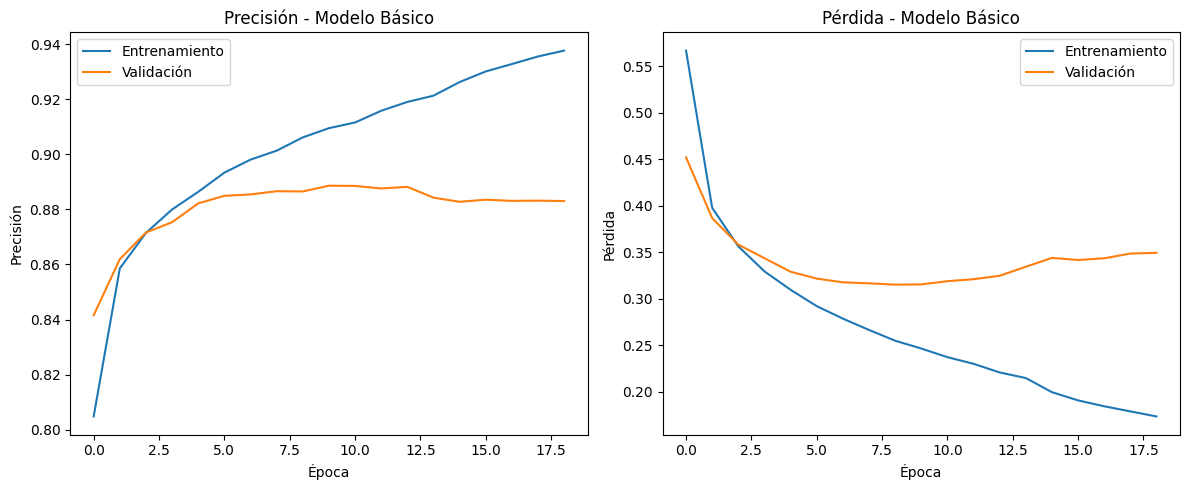

In [11]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Gráfico de precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Precisión - {model_name}')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    # Gráfico de pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Pérdida - {model_name}')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Visualizar el progreso de entrenamiento del modelo 1
plot_training_history(history1, 'Modelo Básico')


### 📈 Análisis del Entrenamiento — Modelo Básico

Esta visualización nos muestra cómo evolucionan la **precisión** y la **pérdida** tanto en el conjunto de entrenamiento como en el de validación a lo largo de las épocas.

---

#### 🔹 Gráfica izquierda: *Precisión (Precision)*

- La línea azul representa la precisión en el **entrenamiento**.
- La línea naranja es la precisión en la **validación**.

**¿Qué vemos?**
- Al inicio, ambas líneas suben, lo cual es bueno: el modelo está aprendiendo.
- A partir de la época ~7-8, la precisión en validación **se estanca** o incluso baja ligeramente, mientras que la de entrenamiento **sigue subiendo**.
  
📌 **Conclusión:** Esto indica que el modelo **empieza a sobreajustarse** (*overfitting*), es decir, aprende muy bien el entrenamiento, pero ya no mejora (y hasta empeora) en datos nuevos.

---

#### 🔹 Gráfica derecha: *Pérdida (Loss)*

- De nuevo, azul es para entrenamiento y naranja para validación.

**¿Qué vemos?**
- La pérdida en entrenamiento **disminuye de forma constante**, lo cual es normal.
- En validación también baja al principio, pero luego **comienza a subir** a partir de la época ~10.

📌 **Conclusión:** Este aumento en la pérdida de validación confirma que el modelo está empezando a memorizar los datos del entrenamiento y **ya no generaliza bien**.

---

### 🎓 ¿Qué podemos aprender?

- El modelo básico **necesita regularización** (como Dropout o Early Stopping) para evitar el sobreajuste.
- También podríamos detener el entrenamiento antes (época 8–10) para obtener mejor desempeño en validación.


### Entrenamiento del Modelo 2: MLP con Regularización

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6807 - loss: 0.9377 - val_accuracy: 0.8196 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8244 - loss: 0.5020 - val_accuracy: 0.8502 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8388 - loss: 0.4528 - val_accuracy: 0.8637 - val_loss: 0.3735 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8463 - loss: 0.4330 - val_accuracy: 0.8633 - val_loss: 0.3738 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8536 - loss: 0.4106 - val_accuracy: 0.8692 - val_loss: 0.3619 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8583 - loss: 0.3944 - val_accuracy: 0.8716 - val_loss: 0.3506 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8624 - loss: 0.3903

Tiempo de entrenamiento del modelo 2: 200.33 segundos


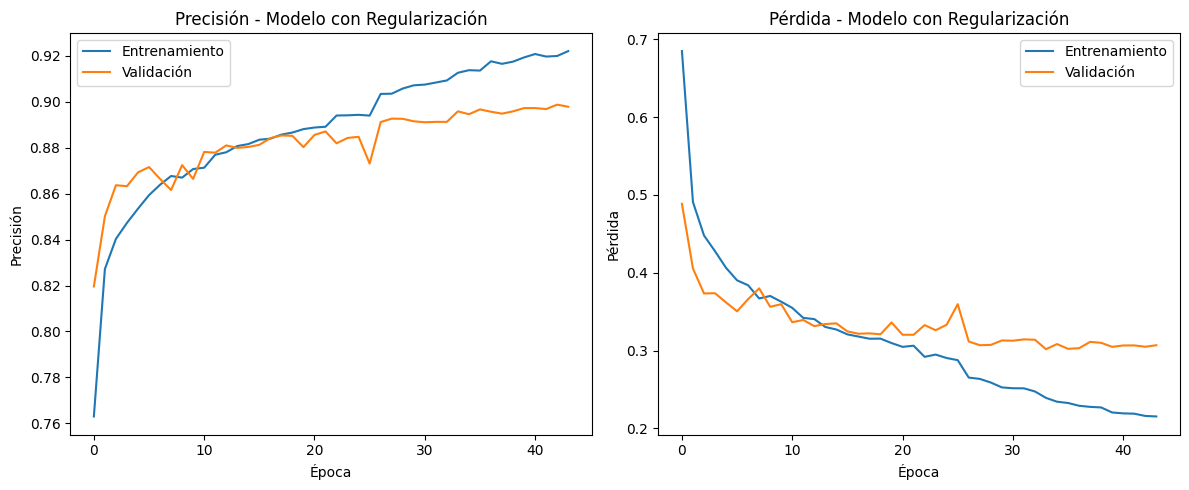

In [12]:
# Comienza a medir el tiempo de entrenamiento para el modelo con regularización
start_time = time.time()

# Entrenamiento del modelo2 (modelo con regularización):
# - X_train_final, y_train_final: Datos de entrenamiento y etiquetas correspondientes.
# - epochs=50: Se entrena el modelo durante un máximo de 50 épocas (el entrenamiento podrá detenerse antes si se activa EarlyStopping).
# - batch_size=128: Se utiliza un tamaño de lote de 128 muestras en cada actualización.
# - validation_data=(X_val, y_val): Se asigna un conjunto de validación para monitorear el desempeño del modelo en datos no vistos durante el entrenamiento.
# - callbacks=callbacks: Se aplican los callbacks configurados (EarlyStopping y ReduceLROnPlateau) para mejorar el proceso de entrenamiento y evitar el sobreajuste.
# - verbose=1: Permite que se muestren mensajes detallados del proceso de entrenamiento en la consola.
history2 = model2.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Se calcula el tiempo total de entrenamiento restando el tiempo actual al tiempo de inicio
model2_time = time.time() - start_time
print(f"Tiempo de entrenamiento del modelo 2: {model2_time:.2f} segundos")

# Guardar el modelo entrenado:
# Se utiliza el método save() de Keras para guardar el modelo en el archivo 'fashion_mnist_model2.h5'.
# Esto permite reutilizar o desplegar el modelo en futuras ocasiones sin necesidad de reentrenarlo.
model2.save('fashion_mnist_model2.h5')

# Visualizar el progreso del entrenamiento:
# Se llama a la función plot_training_history, que se asume está definida en algún lugar del código,
# para mostrar gráficas que revelen el comportamiento de las métricas de entrenamiento (por ejemplo, pérdida y exactitud)
# a lo largo de las épocas. Se pasa el historial de entrenamiento y un título descriptivo.
plot_training_history(history2, 'Modelo con Regularización')

### Entrenamiento del Modelo 3: MLP Profundo


Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6335 - loss: 1.0939 - val_accuracy: 0.8360 - val_loss: 0.4473 - learning_rate: 5.0000e-04
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8114 - loss: 0.5476 - val_accuracy: 0.8502 - val_loss: 0.4008 - learning_rate: 5.0000e-04
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8307 - loss: 0.4884 - val_accuracy: 0.8546 - val_loss: 0.3931 - learning_rate: 5.0000e-04
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8397 - loss: 0.4559 - val_accuracy: 0.8543 - val_loss: 0.3987 - learning_rate: 5.0000e-04
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8433 - loss: 0.4419 - val_accuracy: 0.8485 - val_loss: 0.4033 - learning_rate: 5.0000e-04
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8461 - loss: 0.4280 - val_accuracy: 0.8643 - val_loss: 0.3678 - learning_rate: 5.0000e-04
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/ste

Tiempo de entrenamiento del modelo 3: 735.81 segundos


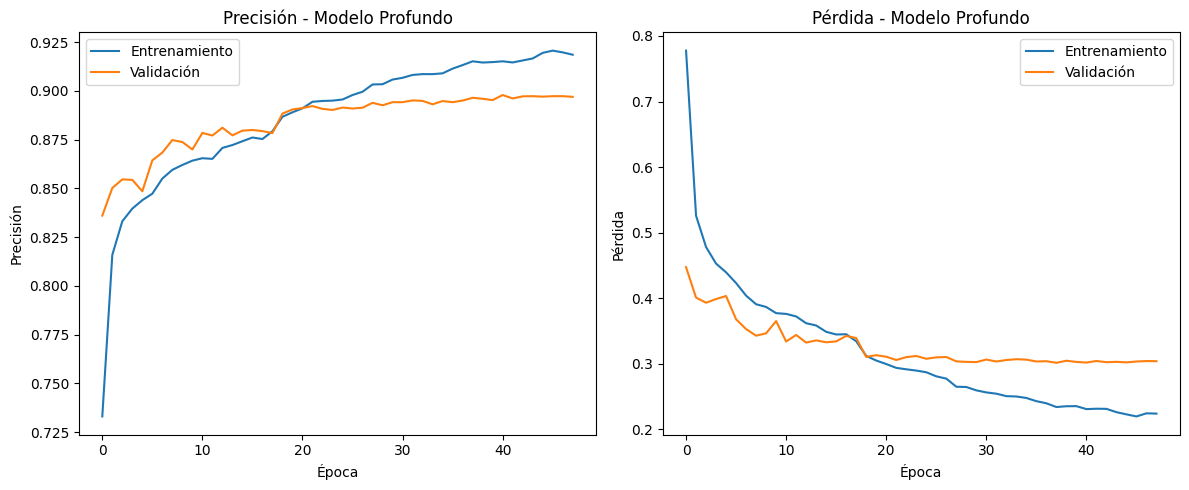

In [13]:
# Iniciar la medición del tiempo de entrenamiento para el modelo profundo (model3)
start_time = time.time()

# Entrenamiento del modelo profundo:
# - X_train_final, y_train_final: Conjunto de datos de entrenamiento con sus respectivas etiquetas.
# - epochs=50: El entrenamiento se realizará hasta 50 épocas (podría detenerse antes si se cumple la condición de EarlyStopping).
# - batch_size=64: Se utiliza un tamaño de lote (batch size) menor que en modelos anteriores, lo cual es común en modelos más complejos para permitir un ajuste más fino.
# - validation_data=(X_val, y_val): Se proporciona un conjunto de datos de validación para evaluar el desempeño del modelo en cada época.
# - callbacks=callbacks: Se pasan los callbacks (como EarlyStopping y ReduceLROnPlateau) para optimizar el proceso de entrenamiento y evitar el sobreajuste.
# - verbose=1: Permite imprimir información detallada sobre el progreso del entrenamiento en la consola.
history3 = model3.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,  # Tamaño de lote más pequeño para el modelo más complejo
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Se calcula el tiempo total de entrenamiento restando el tiempo actual del tiempo inicial registrado.
model3_time = time.time() - start_time
print(f"Tiempo de entrenamiento del modelo 3: {model3_time:.2f} segundos")

# Guardar el modelo entrenado:
# El método model3.save() guarda el modelo completo (arquitectura, pesos y configuración del optimizador)
# en un archivo .h5, permitiendo su posterior reutilización o despliegue sin necesidad de reentrenarlo.
model3.save('fashion_mnist_model3.h5')

# Visualizar el progreso del entrenamiento:
# Se llama a la función plot_training_history, la cual se encarga de graficar las métricas de entrenamiento
# (como la pérdida y la exactitud) registradas en history3 a lo largo de las épocas.
# En este caso, se le asigna el título 'Modelo Profundo' para identificar la gráfica.
plot_training_history(history3, 'Modelo Profundo')

## Evaluación de modelos

Evaluaremos el rendimiento de cada modelo utilizando diferentes métricas como accuracy, precision, recall y F1-score.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Evaluación del Modelo Básico ---
Accuracy: 0.8794
Precision: 0.8789
Recall: 0.8794
F1-score: 0.8785


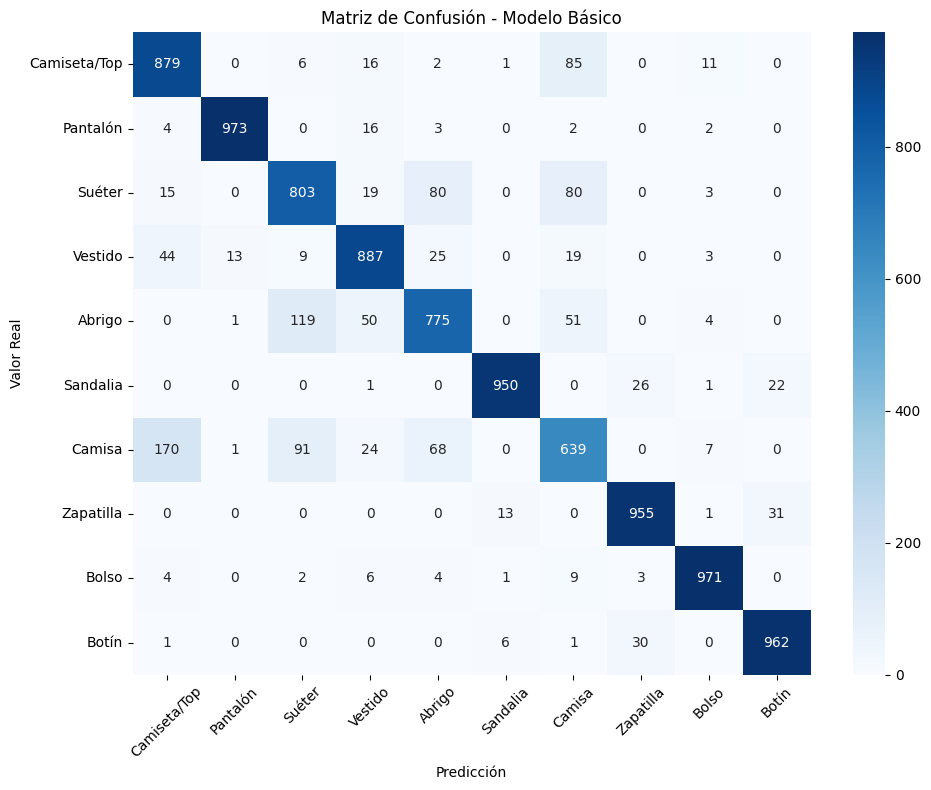


Reporte de Clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.79      0.88      0.83      1000
    Pantalón       0.98      0.97      0.98      1000
      Suéter       0.78      0.80      0.79      1000
     Vestido       0.87      0.89      0.88      1000
      Abrigo       0.81      0.78      0.79      1000
    Sandalia       0.98      0.95      0.96      1000
      Camisa       0.72      0.64      0.68      1000
   Zapatilla       0.94      0.95      0.95      1000
       Bolso       0.97      0.97      0.97      1000
       Botín       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluación del Modelo con Regularización ---
Accuracy: 0.8874
Precision: 0.8872
Recall: 0.8874
F1-score: 0.8871


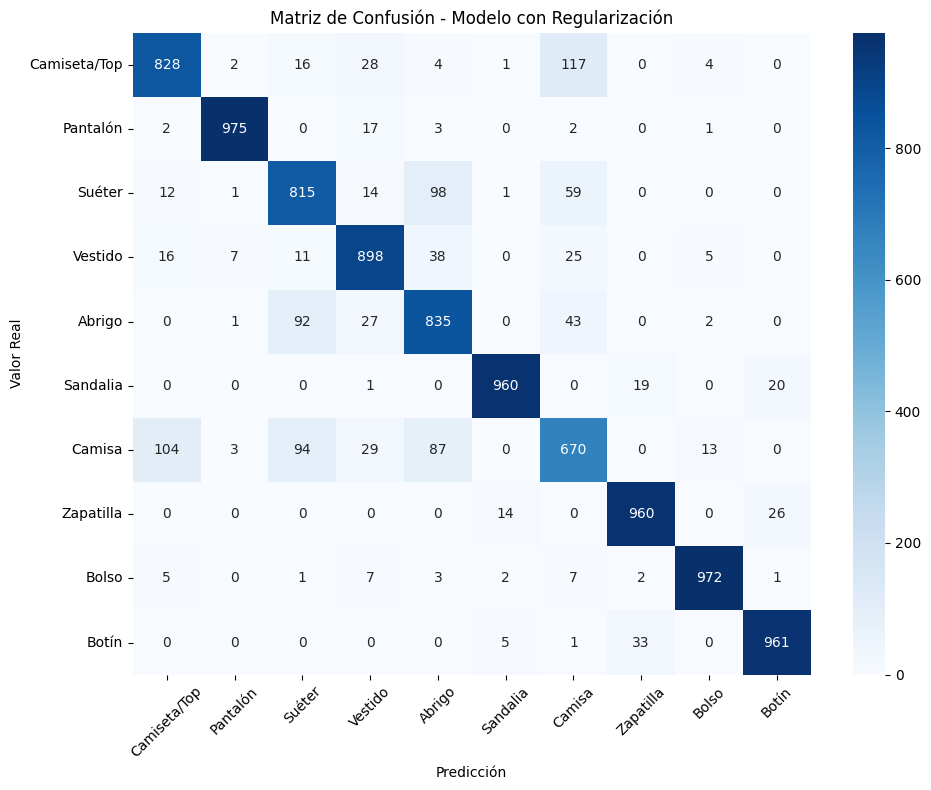


Reporte de Clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.86      0.83      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.79      0.81      0.80      1000
     Vestido       0.88      0.90      0.89      1000
      Abrigo       0.78      0.83      0.81      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.73      0.67      0.70      1000
   Zapatilla       0.95      0.96      0.95      1000
       Bolso       0.97      0.97      0.97      1000
       Botín       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Evaluación del Modelo Profundo ---
Accuracy: 0.8916
Precision: 0.8918
Recall: 0.8916
F1-score: 0.8915


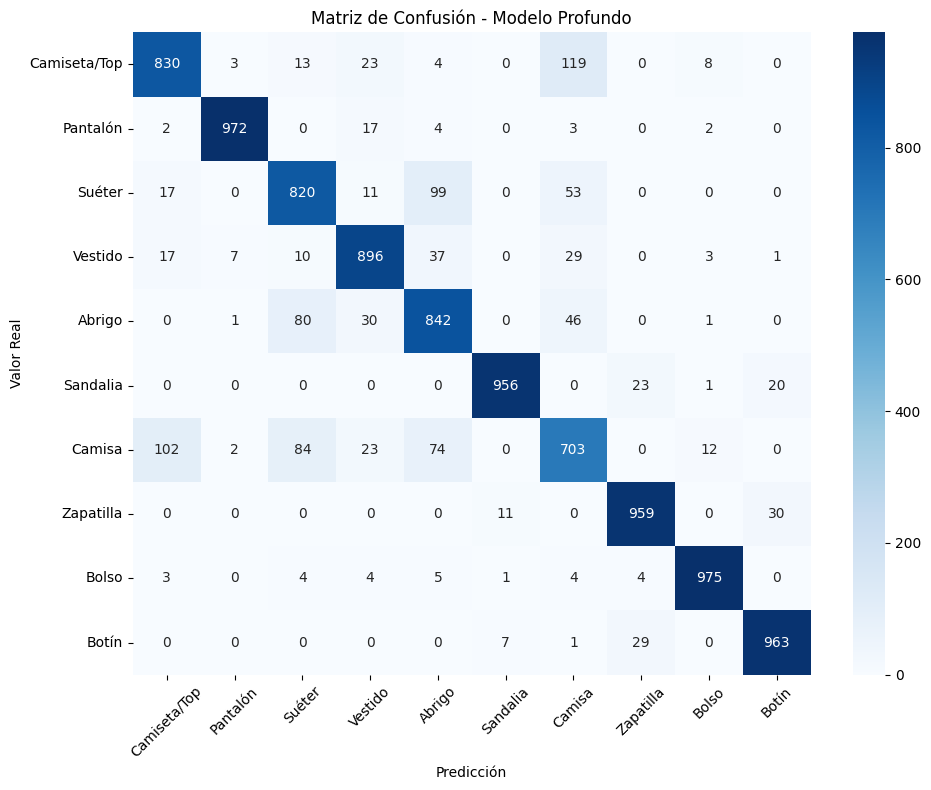


Reporte de Clasificación:
              precision    recall  f1-score   support

Camiseta/Top       0.85      0.83      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.81      0.82      0.82      1000
     Vestido       0.89      0.90      0.89      1000
      Abrigo       0.79      0.84      0.82      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.73      0.70      0.72      1000
   Zapatilla       0.94      0.96      0.95      1000
       Bolso       0.97      0.97      0.97      1000
       Botín       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
def evaluate_model(model, X_test, y_test, y_test_onehot, model_name):
    # Predecir las probabilidades de cada clase para las muestras del conjunto de prueba.
    # model.predict(X_test) devuelve, para cada ejemplo, un vector con las probabilidades de pertenecer a cada clase.
    y_pred_prob = model.predict(X_test)

    # Convertir las probabilidades en etiquetas de clase.
    # np.argmax se usa para obtener el índice (etiqueta) de la clase con mayor probabilidad para cada muestra.
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Calcular métricas de evaluación:
    # 1. Accuracy (exactitud): Proporción de predicciones correctas.
    acc = accuracy_score(y_test, y_pred)

    # 2. Precision (precisión): Medida de la exactitud de las predicciones positivas, ponderadas en caso multiclase.
    prec = precision_score(y_test, y_pred, average='weighted')

    # 3. Recall (sensibilidad o exhaustividad): Medida de la capacidad para encontrar todos los casos positivos, ponderada.
    rec = recall_score(y_test, y_pred, average='weighted')

    # 4. F1-score: Media armonica entre precisión y recall, dando una sola medida de desempeño.
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Imprimir las métricas calculadas junto con el nombre del modelo evaluado.
    print(f"\n--- Evaluación del {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Visualizar la matriz de confusión:
    # Crear una figura con un tamaño adecuado para visualizar la matriz.
    plt.figure(figsize=(10, 8))

    # Calcular la matriz de confusión usando los valores reales y las predicciones.
    cm = confusion_matrix(y_test, y_pred)

    # Graficar la matriz de confusión utilizando un mapa de calor.
    # sns.heatmap se emplea para representar gráficamente la matriz;
    # 'annot=True' muestra los números en cada celda,
    # 'fmt="d"' indica formato entero, y 'cmap="Blues"' establece la paleta de colores.
    # Los argumentos xticklabels y yticklabels se configuran con la lista de nombres de clases (class_names).
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

    # Configurar título y etiquetas de la gráfica.
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')

    # Rota las etiquetas del eje x para mejorar la legibilidad.
    plt.xticks(rotation=45)
    plt.tight_layout()  # Ajusta automáticamente los márgenes para que la gráfica se vea bien.
    plt.show()  # Muestra la gráfica en pantalla.

    # Imprimir el reporte de clasificación:
    # El reporte detalla las métricas (precisión, recall y F1-score) para cada clase de forma individual.
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Retornar las métricas calculadas para que puedan utilizarse en otras partes del código si es necesario.
    return acc, prec, rec, f1

# Evaluar el modelo 1 (Modelo Básico)
acc1, prec1, rec1, f1_1 = evaluate_model(model1, X_test_flat, y_test, y_test_onehot, "Modelo Básico")

# Evaluar el modelo 2 (Modelo con Regularización)
acc2, prec2, rec2, f1_2 = evaluate_model(model2, X_test_flat, y_test, y_test_onehot, "Modelo con Regularización")

# Evaluar el modelo 3 (Modelo Profundo)
acc3, prec3, rec3, f1_3 = evaluate_model(model3, X_test_flat, y_test, y_test_onehot, "Modelo Profundo")


## Comparación de modelos

Ahora compararemos los tres modelos para ver cuál ofrece mejor rendimiento:


--- Comparación de Modelos ---
         Modelo  Accuracy  Precision  Recall  F1-Score  \
0        Básico    0.8794   0.878893  0.8794  0.878546   
1  Regularizado    0.8874   0.887225  0.8874  0.887050   
2      Profundo    0.8916   0.891763  0.8916  0.891515   

   Tiempo Entrenamiento (s)  
0                 52.342152  
1                195.406570  
2                692.815245  


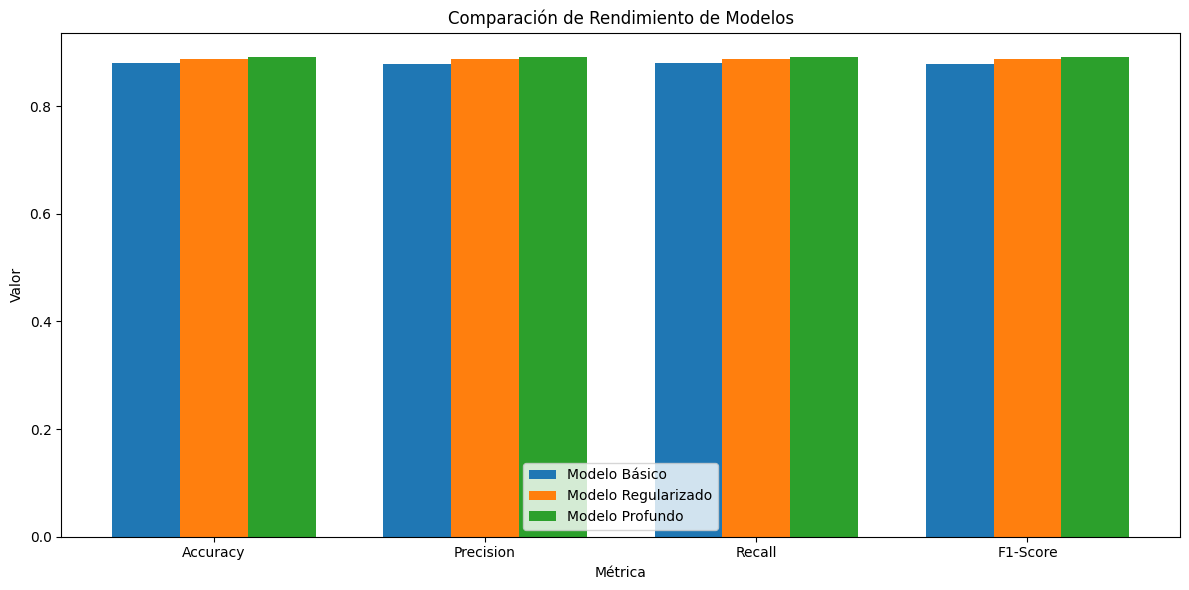

In [ ]:
# Creamos un DataFrame de pandas para almacenar y comparar las métricas de los tres modelos:
# - 'Modelo': Nombre o identificador del modelo.
# - 'Accuracy': Precisión global del modelo.
# - 'Precision': Medida de precisión (ponderada en caso de múltiples clases).
# - 'Recall': Medida de sensibilidad (ponderada).
# - 'F1-Score': Media armónica de precisión y recall.
# - 'Tiempo Entrenamiento (s)': Tiempo total invertido en el entrenamiento del modelo.
models_comparison = pd.DataFrame({
    'Modelo': ['Básico', 'Regularizado', 'Profundo'],
    'Accuracy': [acc1, acc2, acc3],
    'Precision': [prec1, prec2, prec3],
    'Recall': [rec1, rec2, rec3],
    'F1-Score': [f1_1, f1_2, f1_3],
    'Tiempo Entrenamiento (s)': [model1_time, model2_time, model3_time]
})

# Imprimir en consola el DataFrame con la comparación de modelos
print("\n--- Comparación de Modelos ---")
print(models_comparison)

# Visualización de las métricas de rendimiento (excluyendo el tiempo) mediante un gráfico de barras:
plt.figure(figsize=(12, 6))  # Establece el tamaño de la figura para una visualización adecuada

# Definir las métricas que se desean comparar
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
# Crear un arreglo de posiciones para cada métrica en el eje x
x = np.arange(len(metrics))
# Definir el ancho de cada barra para que las mismas no se sobrepongan
width = 0.25

# Graficar las barras para cada modelo:
# - Para 'Modelo Básico' se desplaza a la izquierda de la posición central (x - width)
plt.bar(x - width, models_comparison.iloc[0, 1:5], width, label='Modelo Básico')
# - Para 'Modelo Regularizado' se usa la posición central (x)
plt.bar(x, models_comparison.iloc[1, 1:5], width, label='Modelo Regularizado')
# - Para 'Modelo Profundo' se desplaza a la derecha de la posición central (x + width)
plt.bar(x + width, models_comparison.iloc[2, 1:5], width, label='Modelo Profundo')

# Configuración de etiquetas y título para el gráfico:
plt.xlabel('Métrica')             # Etiqueta para el eje x
plt.ylabel('Valor')               # Etiqueta para el eje y
plt.title('Comparación de Rendimiento de Modelos')  # Título del gráfico
plt.xticks(x, metrics)            # Asigna las etiquetas (nombres de métricas) a cada posición x
plt.legend()                      # Muestra una leyenda para identificar cada modelo

plt.tight_layout()                # Ajusta el layout para que no se superpongan elementos
plt.show()                        # Muestra el gráfico en pantalla

Proporción de predicciones correctas (positivas y negativas) sobre el total de predicciones.

Proporción de verdaderos positivos entre todas las predicciones positivas.

### 📊 Comparación de Modelos — ¿Qué nos dice esta gráfica?

En la parte superior vemos una tabla con las métricas de evaluación de tres modelos distintos:  
- **Modelo Básico**  
- **Modelo Regularizado**  
- **Modelo Profundo**

abajo está la gráfica que visualiza esa información. Vamos a interpretarlo por partes:

---

### 🔎 1. **Métricas de rendimiento (Accuracy, Precision, Recall, F1-Score)**

Estas métricas nos indican **qué tan bien clasifica cada modelo**:

- **Accuracy**: Qué porcentaje de predicciones fueron correctas.
- **Precision**: De todas las predicciones positivas, cuántas fueron correctas.
- **Recall**: De todas las clases positivas reales, cuántas logró detectar el modelo.
- **F1-Score**: Un balance entre precision y recall.

#### 📌 Observaciones:
- El **Modelo Profundo** (verde) tiene **las mejores métricas** en todos los aspectos, aunque las diferencias con los otros modelos son **pequeñas**.
- El **Modelo Regularizado** (naranja) también mejora un poco respecto al básico.
- El **Modelo Básico** (azul) es el que rinde menos, pero no por mucho. Aun así, es útil como punto de partida.

---

### ⏱️ 2. **Tiempo de entrenamiento**

En la tabla vemos cuánto tiempo tardó en entrenarse cada modelo:

- Básico: **~52 segundos**
- Regularizado: **~195 segundos**
- Profundo: **~693 segundos**

#### 📌 Conclusión:
- El **Modelo Profundo** logra un mejor rendimiento, **pero a costa de mucho más tiempo de entrenamiento**.
- El **Modelo Regularizado** ofrece una buena relación entre rendimiento y eficiencia.
- Si estás limitado por tiempo o recursos, **el modelo básico no está mal** como punto inicial.


## Visualización de Predicciones

Finalmente, visualizaremos algunas predicciones del mejor modelo para ver su rendimiento en ejemplos concretos:

El mejor modelo según F1-Score es: Profundo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


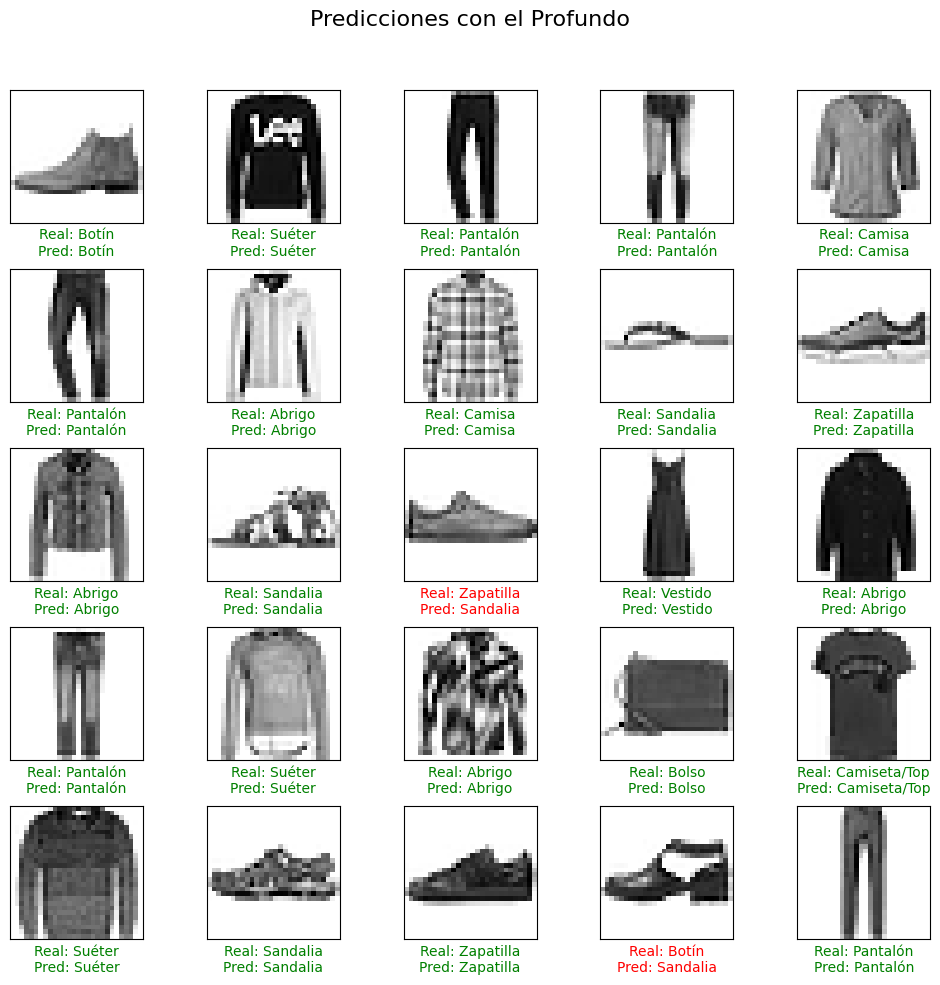

In [ ]:
# Se determina el mejor modelo basándose en el valor del F1-Score.
# Se utiliza idxmax() para obtener el índice del modelo con la mayor puntuación de F1.
best_model_idx = models_comparison['F1-Score'].idxmax()

# Se extrae el nombre del modelo correspondiente a ese índice.
best_model_name = models_comparison.loc[best_model_idx, 'Modelo']
print(f"El mejor modelo según F1-Score es: {best_model_name}")

# Se procede a seleccionar el modelo óptimo de acuerdo al nombre obtenido.
if best_model_name == 'Básico':
    best_model = model1
elif best_model_name == 'Regularizado':
    best_model = model2
else:
    best_model = model3

# Se define la función plot_predictions para visualizar algunas predicciones del modelo.
def plot_predictions(model, X_test, X_test_flat, y_test, class_names, num_samples=25):
    # Se obtienen las predicciones del modelo para las primeras num_samples muestras.
    # La función predict() devuelve las probabilidades de cada clase para cada muestra.
    # Se utiliza np.argmax para determinar la clase con la mayor probabilidad.
    y_pred = np.argmax(model.predict(X_test_flat[:num_samples]), axis=1)

    # Se crea una figura de tamaño adecuado para mostrar las imágenes.
    plt.figure(figsize=(10, 10))

    # Se recorre cada muestra para visualizar la imagen junto con su etiqueta real y la predicción realizada.
    for i in range(num_samples):
        plt.subplot(5, 5, i + 1)  # Se organiza la figura en una cuadrícula de 5x5.
        plt.xticks([])            # Se eliminan las marcas del eje x.
        plt.yticks([])            # Se eliminan las marcas del eje y.
        plt.grid(False)           # Se desactiva la visualización de la cuadrícula.
        plt.imshow(X_test[i], cmap=plt.cm.binary)  # Se muestra la imagen en escala de grises.

        # Se define el color de la etiqueta: verde si la predicción es correcta, rojo si es incorrecta.
        color = 'green' if y_pred[i] == y_test[i] else 'red'
        plt.xlabel(f"Real: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}", color=color)

    # Se ajusta el diseño para evitar superposición entre los elementos gráficos.
    plt.tight_layout()

    # Se establece un título general para la figura, indicando el modelo utilizado en las predicciones.
    plt.suptitle(f'Predicciones con el {best_model_name}', fontsize=16)
    plt.subplots_adjust(top=0.9)  # Se ajusta la posición del título.

    # Finalmente, se muestra el gráfico con las imágenes y sus etiquetas.
    plt.show()

# Se visualizan las predicciones del modelo seleccionado.
plot_predictions(best_model, X_test, X_test_flat, y_test, class_names)


## Análisis del algoritmo de Backpropagation

El algoritmo de backpropagation es fundamental para el entrenamiento de redes neuronales. Veamos cómo funciona conceptualmente en nuestro modelo MLP:

### ¿Cuál es el objetivo?

El objetivo de esta sección es que comprendan, al menos de forma conceptual, cómo este algoritmo permite que el modelo mejore después de cada iteración. En nuestro modelo MLP, *backpropagation* calcula el error que hay entre la predicción y la etiqueta real, y lo utiliza para actualizar los pesos de la red desde la capa de salida hasta las capas iniciales.

Aunque no entraremos en el detalle matemático completo, es importante que se queden con la idea central: **la red aprende a partir de sus errores**, y este algoritmo es el responsable de que eso ocurra.

In [14]:
# La siguiente función implementa una versión simplificada y manual del algoritmo de backpropagation.
# Se utiliza una red neural básica con una sola capa oculta y una capa de salida.
# La idea es ilustrar de forma simple cómo se calculan los gradientes y cómo se actualizan los pesos.

def simple_backpropagation_example():
    # Se establece la arquitectura de la red:
    # La red consta de una capa de entrada (x) de 784 neuronas (por ejemplo, una imagen aplanada de 28x28 píxeles),
    # una capa oculta con 128 neuronas, y una capa de salida con 10 neuronas (correspondientes a 10 clases).

    # Inicialización de parámetros (pesos y bias):
    # Se inicializan los pesos de manera aleatoria y los bias en cero.
    W1 = np.random.randn(784, 128)  # Pesos que conectan la entrada con la capa oculta.
    b1 = np.zeros(128)              # Bias de la capa oculta.
    W2 = np.random.randn(128, 10)   # Pesos que conectan la capa oculta con la capa de salida.
    b2 = np.zeros(10)               # Bias de la capa de salida.

    # Definición del hiperparámetro de la tasa de aprendizaje.
    learning_rate = 0.01

    # Se realiza un forward pass con un único ejemplo:
    # Se selecciona la primera imagen del conjunto de entrenamiento y su etiqueta correspondiente.
    x = X_train_flat[0:1]          # Selección de una sola imagen (entrada).
    y_true = y_train_onehot[0:1]     # Etiqueta real codificada en one-hot para esa imagen.

    # Cálculo del forward pass en la capa oculta:
    # Se realiza una multiplicación matricial entre la entrada y los pesos de la capa 1, se suma el bias, y se aplica la función ReLU.
    z1 = np.dot(x, W1) + b1
    h = np.maximum(0, z1)          # Función de activación ReLU aplicada a la salida de la capa oculta.

    # Cálculo del forward pass en la capa de salida:
    # Se multiplica la activación de la capa oculta por los pesos de la capa 2, se suma el bias, y se utiliza softmax
    # para convertir los logits en probabilidades.
    z2 = np.dot(h, W2) + b2
    y_pred = np.exp(z2) / np.sum(np.exp(z2), axis=1, keepdims=True)  # Función softmax para la capa de salida.

    # Cálculo del error mediante la pérdida de entropía cruzada categórica:
    # Se compara la salida predicha (y_pred) con la etiqueta real (y_true).
    loss = -np.sum(y_true * np.log(y_pred))

    # Inicio de la fase de Backpropagation:
    # Se calculan los gradientes de la función de pérdida con respecto a los distintos parámetros de la red.

    # 1. Gradiente de la pérdida respecto a la salida del modelo.
    # Para la entropía cruzada en conjunto con softmax, este gradiente es la diferencia entre las predicciones y las etiquetas verdaderas.
    dL_dy = y_pred - y_true

    # 2. Gradiente respecto a los pesos de la capa de salida.
    # Se utiliza la regla de la cadena para propagar el error desde la capa de salida hacia los pesos (W2) y los bias (b2).
    dL_dW2 = np.dot(h.T, dL_dy)
    dL_db2 = np.sum(dL_dy, axis=0)

    # 3. Gradiente respecto a la activación de la capa oculta.
    # Se propaga el error desde la capa de salida a la capa oculta usando la transpuesta de los pesos de la capa de salida.
    dL_dh = np.dot(dL_dy, W2.T)

    # 4. Gradiente respecto a la entrada de la función de activación ReLU en la capa oculta.
    # Se crea una copia del gradiente anterior y se modifica según la derivada de ReLU,
    # que es 1 cuando z1 es positivo y 0 cuando z1 es menor o igual a cero.
    dL_dz1 = dL_dh.copy()
    dL_dz1[z1 <= 0] = 0  # La derivada de ReLU es cero en los valores no positivos.

    # 5. Gradiente respecto a los pesos de la capa oculta.
    dL_dW1 = np.dot(x.T, dL_dz1)
    dL_db1 = np.sum(dL_dz1, axis=0)

    # Actualización de parámetros:
    # Se actualizan los pesos y biases de cada capa utilizando el gradiente descendente.
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2

    # La función retorna la pérdida inicial y las formas de los gradientes calculados,
    # lo cual permite verificar el correcto funcionamiento del algoritmo de backpropagation.
    return {
        'initial_loss': loss,
        'gradients': {
            'dL_dW1': dL_dW1,
            'dL_db1': dL_db1,
            'dL_dW2': dL_dW2,
            'dL_db2': dL_db2
        }
    }

# Se ilustra el concepto de backpropagation ejecutando la función definida.
backprop_example = simple_backpropagation_example()

# Se imprime la pérdida inicial para evaluar el error antes de la actualización de parámetros.
print("Pérdida inicial:", backprop_example['initial_loss'])

# Se muestran las formas (shapes) de los gradientes calculados, lo cual es útil para confirmar que
# las dimensiones concuerdan con las de los pesos y biases correspondientes.
print("\nForma de los gradientes:")
for key, value in backprop_example['gradients'].items():
    print(f"{key}: {value.shape}")


Pérdida inicial: 31.59767161645119

Forma de los gradientes:
dL_dW1: (784, 128)
dL_db1: (128,)
dL_dW2: (128, 10)
dL_db2: (10,)


### 🔢 **¿Qué significa "Pérdida inicial: 398.226"?**

La **pérdida (loss)** es una medida de qué tan mal está funcionando el modelo en una etapa específica del entrenamiento. En este caso, es **la pérdida justo al inicio**, antes de que el modelo aprenda nada.  
Un valor como **398.226** sugiere que el modelo está bastante perdido, lo cual es totalmente normal en la primera iteración, sobre todo si está usando *cross-entropy* como función de pérdida y aún no ha ajustado pesos.

---

### 🧠 **¿Qué significan los gradientes (`dL_dW1`, `dL_db1`, etc.)?**

Los gradientes indican **cuánto debería cambiar cada peso o sesgo (bias)** para reducir la pérdida. En otras palabras, nos dicen hacia dónde debe moverse cada parámetro del modelo para mejorar.

#### En detalle:

- **`dL_dW1: (784, 128)`**  
  → Es el gradiente de la pérdida respecto a la matriz de pesos de la **primera capa oculta**.  
  → Dimensiones: 784 entradas (pixeles de una imagen de 28x28) × 128 neuronas ocultas.

- **`dL_db1: (128,)`**  
  → Es el gradiente respecto a los **sesgos de la primera capa**.  
  → Hay un sesgo por cada neurona, por eso tiene 128 valores.

- **`dL_dW2: (128, 10)`**  
  → Es el gradiente de los pesos que conectan la capa oculta con la **capa de salida**.  
  → 128 neuronas ocultas × 10 clases (ropa, zapatillas, etc.).

- **`dL_db2: (10,)`**  
  → Gradiente de los **sesgos de la capa de salida**.  
  → Uno por cada clase.

---

### 🧪 En resumen:
- Estamos viendo el resultado del primer paso del *backpropagation*.
- Los gradientes son lo que se va a usar para actualizar los pesos y mejorar la predicción.
- El valor alto de pérdida al inicio es normal. Lo importante es que empiece a bajar con el entrenamiento.

## Análisis de sensibilidad de hiperparámetros

Ahora, realizaremos un breve análisis para ver cómo afectan algunos hiperparámetros al rendimiento del modelo:

### ¿Cuál es el objetivo?

El objetivo es que puedan observar cómo pequeños cambios en parámetros como la tasa de aprendizaje (*learning rate*), el tamaño del *batch* o el número de épocas pueden tener un impacto significativo en el desempeño de la red neuronal.  

Este tipo de análisis es clave cuando se busca optimizar un modelo, ya que permite tomar decisiones más informadas al momento de entrenarlo. Además, les ayudará a desarrollar un mejor criterio para ajustar configuraciones en futuros proyectos de *Deep Learning*.


Entrenando modelo de prueba 1...

Entrenando modelo de prueba 2...

Entrenando modelo de prueba 3...

Entrenando modelo de prueba 4...

Entrenando modelo de prueba 5...

--- Análisis de sensibilidad de hiperparámetros ---
                                           config  val_accuracy  val_loss
0   Units: 128, Dropout: 0.2, LR: 0.001, BN: True        0.8390  0.435932
1  Units: 128, Dropout: 0.2, LR: 0.001, BN: False        0.8525  0.388380
2   Units: 256, Dropout: 0.2, LR: 0.001, BN: True        0.8515  0.439204
3   Units: 128, Dropout: 0.4, LR: 0.001, BN: True        0.8365  0.448369
4    Units: 128, Dropout: 0.2, LR: 0.01, BN: True        0.8415  0.455270


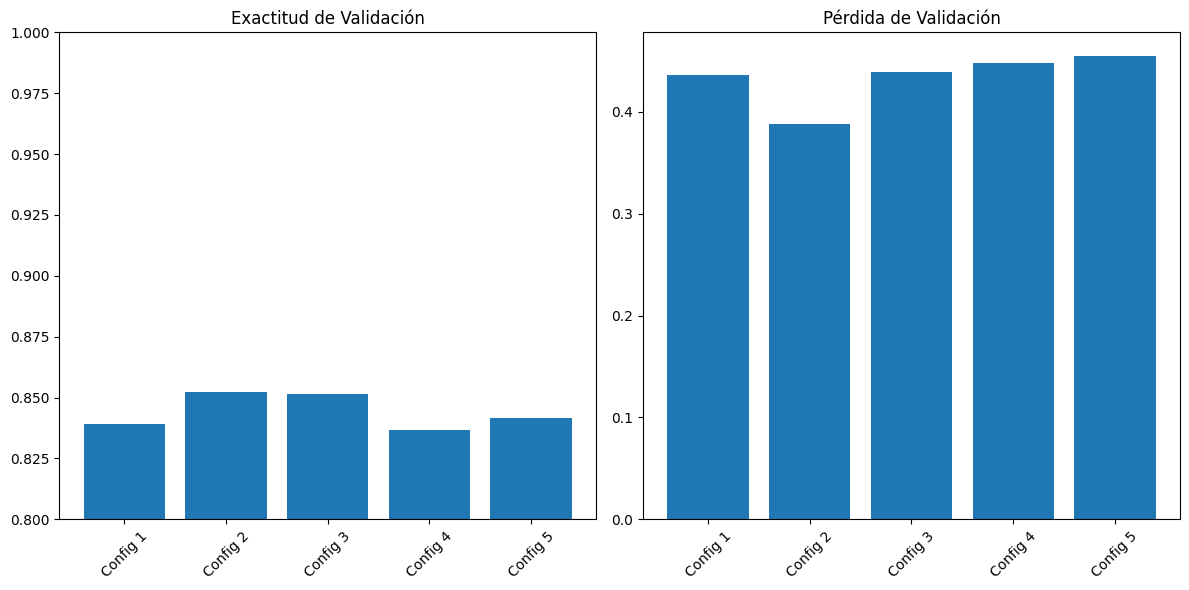

Config 1: Units: 128, Dropout: 0.2, LR: 0.001, BN: True
Config 2: Units: 128, Dropout: 0.2, LR: 0.001, BN: False
Config 3: Units: 256, Dropout: 0.2, LR: 0.001, BN: True
Config 4: Units: 128, Dropout: 0.4, LR: 0.001, BN: True
Config 5: Units: 128, Dropout: 0.2, LR: 0.01, BN: True


In [15]:
def create_test_model(hidden_units, dropout_rate, learning_rate, batch_norm=True):
    # Se inicializa un modelo secuencial para construir la red de forma escalonada.
    model = Sequential()

    # Primera capa densa:
    # Se añade una capa completamente conectada con un número de neuronas especificado por 'hidden_units',
    # empleando la función de activación ReLU, y se define la forma de entrada como un vector de 784 elementos.
    model.add(Dense(hidden_units, activation='relu', input_shape=(784,)))

    # Se añade BatchNormalization si el parámetro batch_norm es True.
    if batch_norm:
        model.add(BatchNormalization())

    # Se incorpora una capa Dropout para regularizar el modelo, descartando aleatoriamente 'dropout_rate' porcentaje de neuronas.
    model.add(Dropout(dropout_rate))

    # Segunda capa densa:
    # Se agrega otra capa densa con la mitad del número de neuronas de la capa anterior, nuevamente usando ReLU.
    model.add(Dense(hidden_units//2, activation='relu'))

    # Se añade nuevamente BatchNormalization condicionalmente.
    if batch_norm:
        model.add(BatchNormalization())

    # Se incorpora una segunda capa Dropout para favorecer la generalización.
    model.add(Dropout(dropout_rate))

    # Capa de salida:
    # Se incluye una capa densa final con 10 neuronas y activación softmax, adecuada para problemas de clasificación multiclase.
    model.add(Dense(10, activation='softmax'))

    # Compilación del modelo:
    # Se configura el modelo utilizando el optimizador Adam con la tasa de aprendizaje indicada.
    # La función de pérdida utilizada es la 'categorical_crossentropy', idónea para clasificación.
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Se definen diferentes configuraciones de hiperparámetros para evaluar cómo afectan el rendimiento del modelo.
configs = [
    {'hidden_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_norm': True},
    {'hidden_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_norm': False},
    {'hidden_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_norm': True},
    {'hidden_units': 128, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_norm': True},
    {'hidden_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'batch_norm': True},
]

# Explicación:
# 1. Configuración base: 128 unidades, dropout 0.2, learning rate 0.001, con batch normalization.
# 2. Sin batch normalization: para analizar el impacto de omitir esta técnica de regularización.
# 3. Incremento en el número de unidades: 256 unidades, para evaluar el efecto de aumentar la capacidad del modelo.
# 4. Aumento del dropout a 0.4: para comprobar si un mayor nivel de regularización mejora la generalización.
# 5. Incremento del learning rate a 0.01: para examinar si una tasa de aprendizaje mayor favorece o perjudica el rendimiento.

# Se selecciona un subconjunto más pequeño de los datos para el entrenamiento y validación, con el fin de ahorrar tiempo en la experimentación.
X_sample, X_val_sample, y_sample, y_val_sample = train_test_split(
    X_train_final[:10000], y_train_final[:10000], test_size=0.2, random_state=42
)

# Se crea una lista para almacenar los resultados de las evaluaciones de cada configuración.
results = []
for i, config in enumerate(configs):
    print(f"\nEntrenando modelo de prueba {i+1}...")
    # Se construye el modelo utilizando la configuración actual.
    model = create_test_model(**config)

    # El entrenamiento se realiza durante 10 épocas con un tamaño de lote de 128, utilizando el subconjunto definido.
    history = model.fit(
        X_sample, y_sample,
        epochs=10,
        batch_size=128,
        validation_data=(X_val_sample, y_val_sample),
        verbose=0
    )

    # Se evalúa el modelo en el conjunto de validación y se obtienen la pérdida y la exactitud.
    val_loss, val_acc = model.evaluate(X_val_sample, y_val_sample, verbose=0)

    # Se prepara una descripción de la configuración para facilitar el análisis comparativo.
    config_desc = f"Units: {config['hidden_units']}, Dropout: {config['dropout_rate']}, " \
                  f"LR: {config['learning_rate']}, BN: {config['batch_norm']}"

    # Se almacena el resultado de esta configuración en la lista results.
    results.append({
        'config': config_desc,
        'val_accuracy': val_acc,
        'val_loss': val_loss
    })

# Se crea un DataFrame de pandas para resumir y visualizar los resultados de las distintas configuraciones.
results_df = pd.DataFrame(results)
print("\n--- Análisis de sensibilidad de hiperparámetros ---")
print(results_df)

# Se procede a visualizar los resultados mediante gráficos de barras.
plt.figure(figsize=(12, 6))

# Se grafica la exactitud de validación para cada configuración.
plt.subplot(1, 2, 1)
plt.bar(range(len(results)), [r['val_accuracy'] for r in results])
plt.xticks(range(len(results)), [f"Config {i+1}" for i in range(len(results))], rotation=45)
plt.title('Exactitud de Validación')
plt.ylim(0.8, 1.0)  # El rango se ajusta en base a los resultados obtenidos.

# Se grafica la pérdida de validación para cada configuración.
plt.subplot(1, 2, 2)
plt.bar(range(len(results)), [r['val_loss'] for r in results])
plt.xticks(range(len(results)), [f"Config {i+1}" for i in range(len(results))], rotation=45)
plt.title('Pérdida de Validación')

plt.tight_layout()
plt.show()

# Se imprime en consola la descripción detallada de cada configuración probada,
# permitiendo una comparación directa entre ellas.
for i, r in enumerate(results):
    print(f"Config {i+1}: {r['config']}")
